In [30]:
import pandas as pd
import ir_datasets
from src.data import DATA_DIR_INTERIM
from topic_gen.evaluate import QrelsEvaluator, CohenKappa, MeanAverageError, AreaUnderReceiver, binarize_qrels
from src.data import load_qrels_from_path
from src.utils import format_score
from topic_gen import logger
logger.setLevel("DEBUG")

### Binary Relevance Labels

In [56]:
# Load generated qrels from path
BASE_DIR = DATA_DIR_INTERIM / "qrels-robust-topics-generated"
predictions, names, metadata = load_qrels_from_path(BASE_DIR)

# binarize qrels
predictions = [binarize_qrels(qrels) for qrels in predictions]

[topic_gen] [WARNING] (data.py:58) Metadata not found for result 2025-11-26_11:53:55, skipping...


In [57]:
# Evaluate qrels
res = QrelsEvaluator.experiment(
    predictions=predictions,
    references=binarize_qrels(ir_datasets.load(
        "disks45/nocr/trec-robust-2004").qrels_iter()),
    measures=[CohenKappa(), MeanAverageError(), AreaUnderReceiver()],
    bootstrap=20,
    names=names)

[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 19/2932 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 11/2940 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 6/2945 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 11/2940 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 9/2942 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 10/2941 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 8/2943 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 16/2935 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 4/2947 qrels in references but not in predictions.


In [ ]:
df = pd.DataFrame(res)
df["score"] = df.apply(format_score, axis=1)
df = df.pivot(index="name", columns="measure", values="score").reset_index()
df = df.merge(metadata, left_on="name", right_on="date")

## Alignment
RQ: How well align generated qrels based on generated topics with the original qrels?
 
- Judgments based on the original topics are always better. Sometimes just a little!
- Some settings show a substantial drop in alignment, for example, for `qwen3-30B` on generated topics with the `trec` prompt with one query variant and one relevant document, the Cohen's $\kappa$ agreement to human labels drops from the substantial agreement of 0.75 to a moderate agreement of 0.52.
- More context always helps.
- Contrastive prompting is the best.

In [61]:
model = "qwen3-30B-no-think"  # df["model"]
prompt_sorter = [
    "topic-query",
    "topic-docs-pos",
    "topic-docs-neg",
    "topic-query-docs-pos",
    "topic-query-docs-neg",
    "topic-contrastive",
    "topic-query-contrastive"
]
df["topics_prompt"] = pd.Categorical(df["topics_prompt"], prompt_sorter)

df[(df["prompt"] == "-DNA-zero-shot") & \
      (df["model"] == model) &
   ((df["model"] == df["topics_model"]) | (df["topics_model"] == "trec assessors"))] \
    .sort_values(by=["model", "topics_prompt"], ascending=[True, True])[["name", "topics_date", "topics_prompt", "model", "topics_nqueries", "topics_ndocspos", "topics_ndocsneg", "CohenKappa", "MeanAverageError", "AreaUnderReceiver"]]

,name,topics_date,topics_prompt,model,topics_nqueries,topics_ndocspos,topics_ndocsneg,CohenKappa,MeanAverageError,AreaUnderReceiver
0,2025-11-26_11:00:41,2025-11-25_13:07:46,topic-query,qwen3-30B-no-think,1.0,0.0,0.0,0.63 ± 0.02,0.18 ± 0.01,0.80 ± 0.01
1,2025-11-26_11:06:29,2025-11-25_13:08:31,topic-query,qwen3-30B-no-think,3.0,0.0,0.0,0.67 ± 0.02,0.16 ± 0.01,0.82 ± 0.01
2,2025-11-26_11:12:21,2025-11-25_13:09:17,topic-query,qwen3-30B-no-think,5.0,0.0,0.0,0.66 ± 0.03,0.16 ± 0.01,0.82 ± 0.01
3,2025-11-26_11:18:15,2025-11-25_13:10:06,topic-query,qwen3-30B-no-think,7.0,0.0,0.0,0.66 ± 0.02,0.16 ± 0.01,0.82 ± 0.02
4,2025-11-26_11:24:12,2025-11-25_13:10:56,topic-docs-pos,qwen3-30B-no-think,0.0,1.0,0.0,0.20 ± 0.02,0.47 ± 0.01,0.66 ± 0.01
5,2025-11-26_11:30:09,2025-11-25_13:12:14,topic-docs-pos,qwen3-30B-no-think,0.0,2.0,0.0,0.25 ± 0.01,0.43 ± 0.02,0.67 ± 0.01
6,2025-11-26_11:36:03,2025-11-25_13:14:00,topic-docs-pos,qwen3-30B-no-think,0.0,3.0,0.0,0.32 ± 0.02,0.37 ± 0.01,0.69 ± 0.01
7,2025-11-26_11:41:58,2025-11-25_13:16:07,topic-docs-pos,qwen3-30B-no-think,0.0,4.0,0.0,0.39 ± 0.03,0.32 ± 0.02,0.72 ± 0.01
8,2025-11-26_11:47:56,2025-11-25_13:18:43,topic-docs-pos,qwen3-30B-no-think,0.0,5.0,0.0,0.44 ± 0.02,0.29 ± 0.02,0.73 ± 0.01


## Plot 

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

In [63]:
def plot_context_sweep(df, topic_prompt: str, measure: str = "CohenKappa"):
    # prepare data
    df_orig = df[df["topics_model"] == "human"]

    df = df[
        (df["prompt"] == "-DNA-zero-shot") & ((df["model"] == df["topics_model"]) | (df["topics_model"] == "human"))]\
        .sort_values(by=["model", "topics_prompt"], ascending=[True, True])[["topics_prompt", "model", "topics_nqueries", "topics_ndocspos", "topics_ndocsneg", "CohenKappa", "MeanAverageError", "AreaUnderReceiver"]]

    df = df[(df["topics_prompt"] == topic_prompt)]
    df[measure] = df[measure].apply(lambda s: float(s.split(" ± ")[0]))

    # plot
    sns.lineplot(data=df, x="topics_nqueries", y=measure,
                 hue="model", markers=True, dashes=False)

    # original topics as dashed lines
    for _, row in df_orig.iterrows():
        plt.axhline(y=float(row[measure].split(" ± ")[0]),
                    linestyle='--', label=f"Original - {row['model']}")
    plt.legend()

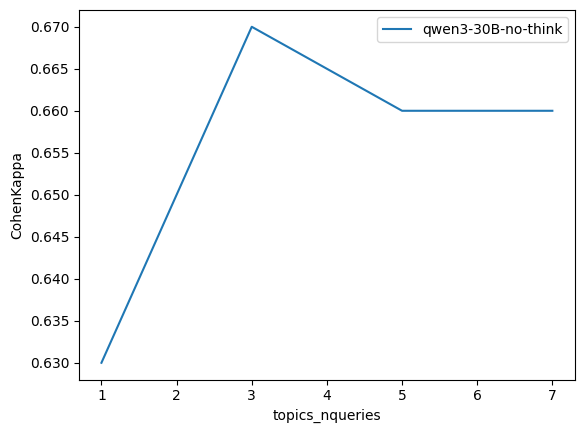

In [64]:
plot_context_sweep(df, topic_prompt="topic-query")

### Per-Topic

In [46]:
# Load generated qrels from path
BASE_DIR = DATA_DIR_INTERIM / "qrels-robust-topics-generated"
predictions, names, metadata = load_qrels_from_path(BASE_DIR)

# binarize qrels
predictions = [binarize_qrels(qrels) for qrels in predictions]

[topic_gen] [WARNING] (data.py:58) Metadata not found for result 2025-11-26_11:53:55, skipping...


In [47]:
# Evaluate qrels
res = QrelsEvaluator.experiment(
    predictions=predictions,
    references=binarize_qrels(ir_datasets.load(
        "disks45/nocr/trec-robust-2004").qrels_iter()),
    measures=[CohenKappa(), MeanAverageError(), AreaUnderReceiver()],
    # bootstrap=20,
    per_query=True,
    names=names)

[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 19/2932 qrels in references but not in predictions.
/home/vscode/.cache/pypoetry/virtualenvs/src-B2WAz2j2-py3.11/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/vscode/.cache/pypoetry/virtualenvs/src-B2WAz2j2-py3.11/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/vscode/.cache/pypoetry/virtualenvs/src-B2WAz2j2-py3.11/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/vscode/.cache/pypoetry/virtualenvs/src-B2WAz2j2-py3.11/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class

In [48]:
df = pd.DataFrame(res)

In [49]:
summary = df.groupby(["topic_id", "measure"])["value"].describe().reset_index()

In [50]:
summary[summary["measure"] == "CohenKappa"].sort_values(by="mean", ascending=True)

,topic_id,measure,count,mean,std,min,25%,50%,75%,max
31,311,CohenKappa,10.0,-0.086287,0.041602,-0.141304,-0.118140,-0.074176,-0.071429,0.000000
103,335,CohenKappa,10.0,-0.067469,0.228218,-0.235294,-0.166667,-0.166667,-0.166667,0.363636
136,346,CohenKappa,10.0,-0.067128,0.120213,-0.235294,-0.193478,0.000000,0.000000,0.068966
349,417,CohenKappa,10.0,-0.066667,0.057378,-0.111111,-0.111111,-0.111111,0.000000,0.000000
145,349,CohenKappa,10.0,-0.023529,0.074407,-0.235294,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
685,681,CohenKappa,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
712,690,CohenKappa,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
715,691,CohenKappa,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
724,694,CohenKappa,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [51]:
df[df["topic_id"] == "309"]

,topic_id,measure,value,name
24,309,CohenKappa,NaN,2025-11-26_11:47:56
25,309,MeanAverageError,0.0,2025-11-26_11:47:56
26,309,AreaUnderReceiver,NaN,2025-11-26_11:47:56
768,309,CohenKappa,NaN,2025-11-26_11:12:21
769,309,MeanAverageError,0.0,2025-11-26_11:12:21
770,309,AreaUnderReceiver,NaN,2025-11-26_11:12:21
1512,309,CohenKappa,NaN,2025-11-26_11:30:09
1513,309,MeanAverageError,0.0,2025-11-26_11:30:09
1514,309,AreaUnderReceiver,NaN,2025-11-26_11:30:09
2256,309,CohenKappa,NaN,2025-11-26_11:06:29
